# RELDEC Orchestration Notebook



This notebook orchestrates end-to-end RELDEC experiments:

- training with checkpoint/resume

- evaluation vs flooding/random/round-robin baselines

- BER/FER/complexity plots



It uses the Python CLIs in the same folder:

- `train_reldec.py`

- `evaluate_reldec.py`

- `reldec_core.py`

## Run Modes



- `RUN_MODE = "smoke"`: quick validation, small sample counts.

- `RUN_MODE = "full"`: spec-scale experiments (long runtime).



For full experiments, expect long training/evaluation times, especially when target frame errors are set to 300 for each SNR point.

In [1]:
from __future__ import annotations



import csv

import json

import shlex

import subprocess

import sys

import time

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np

from IPython.display import display



ROOT = Path.cwd()

if not (ROOT / "RELDEC").exists():

    ROOT = Path("/root/Research/RithvikDecoder/Decoder")



RELDEC_DIR = ROOT / "RELDEC"

TRAIN_SCRIPT = RELDEC_DIR / "train_reldec.py"

EVAL_SCRIPT = RELDEC_DIR / "evaluate_reldec.py"

RUNS_DIR = RELDEC_DIR / "notebook_runs"

RUNS_DIR.mkdir(parents=True, exist_ok=True)



PYTHON = Path(sys.executable)



required_paths = [RELDEC_DIR, TRAIN_SCRIPT, EVAL_SCRIPT]

for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(f"Missing required path: {path}")



print(f"Python executable: {PYTHON}")

print(f"Project root:      {ROOT}")

print(f"RELDEC dir:        {RELDEC_DIR}")

print(f"Runs dir:          {RUNS_DIR}")

Python executable: /root/.pyenv/versions/myenv/bin/python
Project root:      /root/Research/RithvikDecoder/Decoder
RELDEC dir:        /root/Research/RithvikDecoder/Decoder/RELDEC
Runs dir:          /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs


In [2]:
RUN_MODE = "smoke"  # change to "full" for spec-scale runs

RUN_TAG = time.strftime("%Y%m%d_%H%M%S")



CODES = ["ab", "wran"]

METHODS = ["flooding", "random", "round_robin", "reldec"]



if RUN_MODE == "full":

    TRAIN_ARGS = {

        "episodes_per_snr": 2500,

        "checkpoint_every_episodes": 250,

        "log_every": 100,

        "max_episodes": None,

        "snr_override": None,

    }

    EVAL_ARGS = {

        "target_frame_errors": 300,

        "max_frames": 200000,

        "snr_override": None,

    }

else:

    TRAIN_ARGS = {

        "episodes_per_snr": 6,

        "checkpoint_every_episodes": 6,

        "log_every": 3,

        "max_episodes": 24,

        "snr_override": {

            "ab": [1.0, 1.5, 2.0],

            "wran": [1.0, 2.0, 3.0],

        },

    }

    EVAL_ARGS = {

        "target_frame_errors": 8,

        "max_frames": 120,

        "snr_override": {

            "ab": [1.0, 1.5, 2.0],

            "wran": [1.0, 2.0, 3.0],

        },

    }



BASE_SEED = 17

RESUME_IF_AVAILABLE = True



RUN_ROOT = RUNS_DIR / f"run_{RUN_TAG}_{RUN_MODE}"

RUN_ROOT.mkdir(parents=True, exist_ok=True)



print(f"RUN_MODE: {RUN_MODE}")

print(f"RUN_ROOT: {RUN_ROOT}")

print(f"CODES:    {CODES}")

print(f"METHODS:  {METHODS}")

RUN_MODE: smoke
RUN_ROOT: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_195925_smoke
CODES:    ['ab', 'wran']
METHODS:  ['flooding', 'random', 'round_robin', 'reldec']


In [3]:
def _cmd_to_str(cmd: list[str]) -> str:

    return " ".join(shlex.quote(str(x)) for x in cmd)





def run_cmd(cmd: list[str], cwd: Path = ROOT) -> subprocess.CompletedProcess:

    printable = _cmd_to_str(cmd)

    print(f"$ {printable}")

    completed = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)

    if completed.stdout.strip():

        print(completed.stdout)

    if completed.returncode != 0:

        if completed.stderr.strip():

            print(completed.stderr)

        raise RuntimeError(f"Command failed ({completed.returncode}): {printable}")

    return completed





def train_code(code: str, seed: int) -> dict:

    code_root = RUN_ROOT / code

    ckpt_dir = code_root / "checkpoints"

    ckpt_dir.mkdir(parents=True, exist_ok=True)

    latest_ckpt = ckpt_dir / "checkpoint_latest.npz"



    cmd = [

        str(PYTHON),

        str(TRAIN_SCRIPT),

        "--code",

        code,

        "--episodes-per-snr",

        str(TRAIN_ARGS["episodes_per_snr"]),

        "--checkpoint-dir",

        str(ckpt_dir),

        "--checkpoint-every-episodes",

        str(TRAIN_ARGS["checkpoint_every_episodes"]),

        "--log-every",

        str(TRAIN_ARGS["log_every"]),

        "--seed",

        str(seed),

    ]



    if TRAIN_ARGS["max_episodes"] is not None:

        cmd += ["--max-episodes", str(TRAIN_ARGS["max_episodes"])]



    snr_override = TRAIN_ARGS["snr_override"]

    if snr_override is not None and code in snr_override:

        cmd += ["--snr-db"] + [str(v) for v in snr_override[code]]



    if RESUME_IF_AVAILABLE and latest_ckpt.exists():

        cmd += ["--resume", str(latest_ckpt)]



    run_cmd(cmd)



    return {

        "code": code,

        "code_root": code_root,

        "checkpoint_dir": ckpt_dir,

        "checkpoint_latest": latest_ckpt,

        "q_table_npy": ckpt_dir / "q_table_final.npy",

        "summary_json": ckpt_dir / "training_summary.json",

    }





def evaluate_code(code: str, q_table_path: Path, seed: int, methods: list[str]) -> dict:

    code_root = RUN_ROOT / code

    result_dir = code_root / "results"

    result_dir.mkdir(parents=True, exist_ok=True)

    csv_path = result_dir / "eval.csv"

    json_path = result_dir / "eval.json"



    cmd = [

        str(PYTHON),

        str(EVAL_SCRIPT),

        "--code",

        code,

        "--q-table",

        str(q_table_path),

        "--methods",

        *methods,

        "--target-frame-errors",

        str(EVAL_ARGS["target_frame_errors"]),

        "--max-frames",

        str(EVAL_ARGS["max_frames"]),

        "--seed",

        str(seed),

        "--output-csv",

        str(csv_path),

        "--output-json",

        str(json_path),

    ]



    snr_override = EVAL_ARGS["snr_override"]

    if snr_override is not None and code in snr_override:

        cmd += ["--snr-db"] + [str(v) for v in snr_override[code]]



    run_cmd(cmd)

    return {

        "eval_csv": csv_path,

        "eval_json": json_path,

    }





def _parse_value(raw: str):

    lower = raw.lower()

    if lower in {"true", "false"}:

        return lower == "true"

    try:

        if any(ch in raw for ch in [".", "e", "E"]):

            return float(raw)

        return int(raw)

    except ValueError:

        return raw





def read_eval_csv(csv_path: Path) -> list[dict]:

    rows: list[dict] = []

    with open(csv_path, newline="", encoding="utf-8") as fh:

        reader = csv.DictReader(fh)

        for row in reader:

            parsed = {k: _parse_value(v) for k, v in row.items()}

            parsed["eval_csv"] = str(csv_path)

            rows.append(parsed)

    return rows

In [4]:
artifacts: list[dict] = []



for idx, code in enumerate(CODES):

    print("=" * 90)

    print(f"Orchestrating code: {code}")



    train_seed = BASE_SEED + idx

    eval_seed = BASE_SEED + 1000 + idx



    train_info = train_code(code=code, seed=train_seed)

    eval_info = evaluate_code(

        code=code,

        q_table_path=train_info["checkpoint_latest"],

        seed=eval_seed,

        methods=METHODS,

    )



    artifacts.append({**train_info, **eval_info})



print("=" * 90)

print("Orchestration complete.")

for item in artifacts:

    print(f"- {item['code']}: checkpoints={item['checkpoint_dir']} results={item['eval_csv']}")

Orchestrating code: ab
$ /root/.pyenv/versions/myenv/bin/python /root/Research/RithvikDecoder/Decoder/RELDEC/train_reldec.py --code ab --episodes-per-snr 6 --checkpoint-dir /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_195925_smoke/ab/checkpoints --checkpoint-every-episodes 6 --log-every 3 --seed 17 --max-episodes 24 --snr-db 1.0 1.5 2.0
[train] code=ab matrix=/root/Research/RithvikDecoder/Decoder/RELDEC/matrices/H_AB_LDPC_500.csv
[train] H shape=(300, 500) nnz=1500 rate=0.400000
[train] episodes=18 start=0 l_max=50 alpha=0.1 beta=0.9 epsilon=0.6
[train] episode=3/18 mean_reward=0.930667 updates=150
[checkpoint] saved at episode 6
[train] episode=6/18 mean_reward=0.936667 updates=300
[train] episode=9/18 mean_reward=0.936000 updates=450
[checkpoint] saved at episode 12
[train] episode=12/18 mean_reward=0.934333 updates=600
[train] episode=15/18 mean_reward=0.932000 updates=750
[checkpoint] saved at episode 18
[train] episode=18/18 mean_reward=0.928000 updates=

In [5]:
all_rows: list[dict] = []

for item in artifacts:

    all_rows.extend(read_eval_csv(item["eval_csv"]))



all_rows = sorted(all_rows, key=lambda r: (str(r["code"]), float(r["snr_db"]), str(r["method"])))



try:

    import pandas as pd



    df = pd.DataFrame(all_rows)

    cols = [

        "code",

        "method",

        "snr_db",

        "frames",

        "frame_errors",

        "ber",

        "fer",

        "avg_messages",

        "avg_iterations",

    ]

    display(df[cols])

except Exception as exc:

    print(f"pandas display unavailable ({exc}); printing rows instead")

    for row in all_rows:

        print(row)

,code,method,snr_db,frames,frame_errors,ber,fer,avg_messages,avg_iterations
0,ab,flooding,1.0,11,8,0.069818,0.727273,58636.363636,39.090909
1,ab,random,1.0,15,8,0.055867,0.533333,47300.000000,31.533333
2,ab,reldec,1.0,13,8,0.069692,0.615385,54000.000000,36.000000
3,ab,round_robin,1.0,15,8,0.052667,0.533333,48600.000000,32.400000
4,ab,flooding,1.5,35,8,0.026686,0.228571,31028.571429,20.685714
5,ab,random,1.5,62,8,0.012613,0.129032,21338.709677,14.225806
6,ab,reldec,1.5,55,8,0.015018,0.145455,20372.727273,13.581818
7,ab,round_robin,1.5,44,8,0.016864,0.181818,21136.363636,14.090909
8,ab,flooding,2.0,115,8,0.007270,0.069565,19239.130435,12.826087
9,ab,random,2.0,120,5,0.003150,0.041667,12875.000000,8.583333


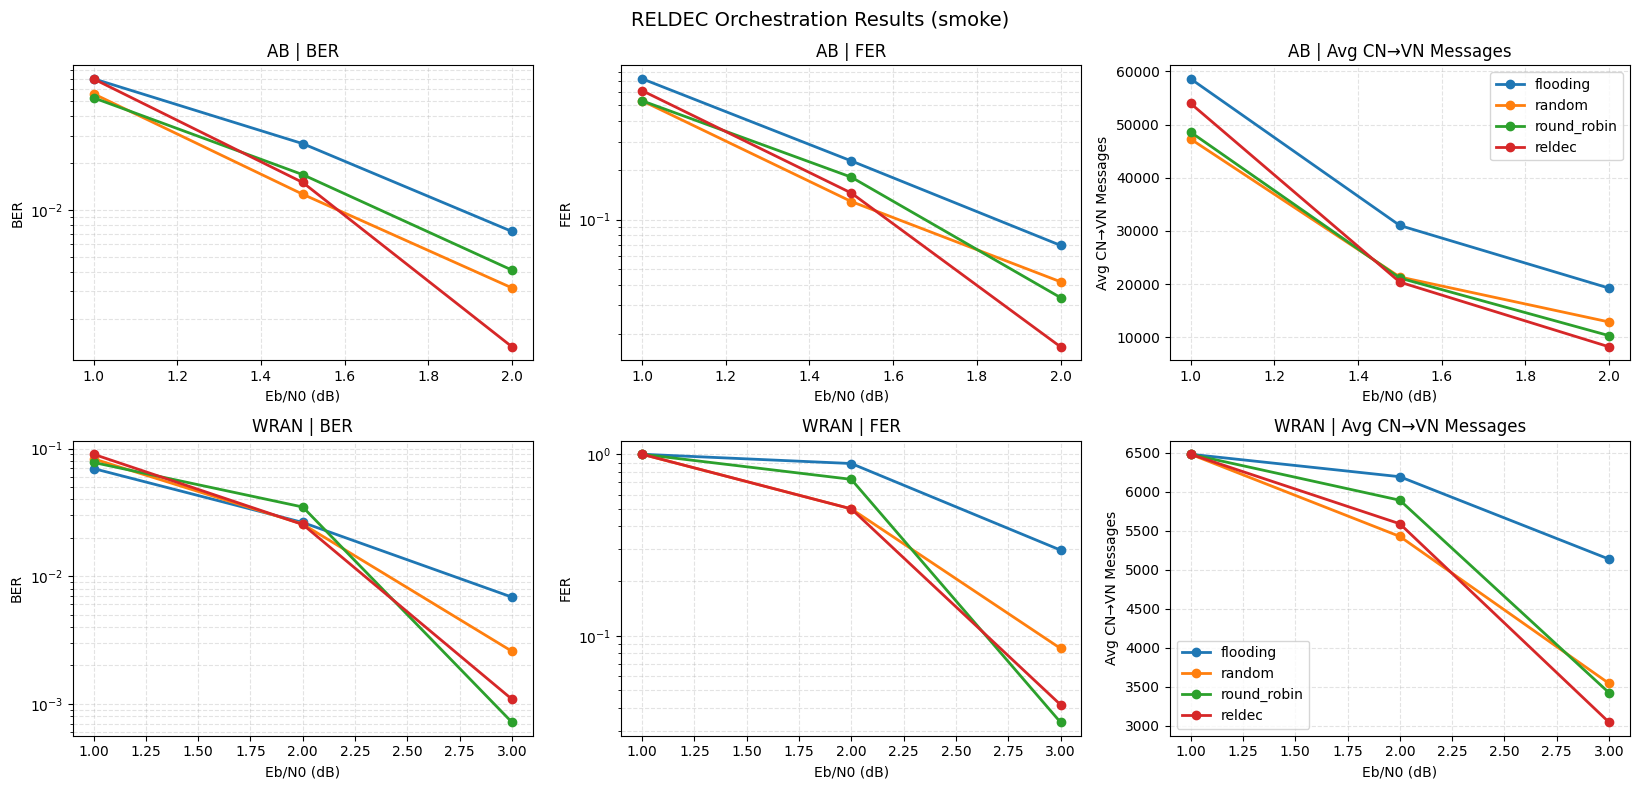

In [6]:
def plot_metric_panels(rows: list[dict], codes: list[str], methods: list[str]) -> None:

    if not rows:

        raise ValueError("No rows available. Run orchestration first.")



    metric_specs = [

        ("ber", "BER", True),

        ("fer", "FER", True),

        ("avg_messages", "Avg CN→VN Messages", False),

    ]



    n_rows = len(codes)

    n_cols = len(metric_specs)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.0 * n_rows), squeeze=False)



    for r, code in enumerate(codes):

        code_rows = [row for row in rows if str(row["code"]).lower() == code.lower()]



        for c, (metric_key, metric_label, logy) in enumerate(metric_specs):

            ax = axes[r][c]

            for method in methods:

                method_rows = [

                    row for row in code_rows if str(row["method"]).lower() == method.lower()

                ]

                if not method_rows:

                    continue



                points = sorted((float(row["snr_db"]), float(row[metric_key])) for row in method_rows)

                x = [p[0] for p in points]

                y = [max(p[1], 1e-12) if logy else p[1] for p in points]



                if logy:

                    ax.semilogy(x, y, marker="o", linewidth=2.0, label=method)

                else:

                    ax.plot(x, y, marker="o", linewidth=2.0, label=method)



            ax.set_title(f"{code.upper()} | {metric_label}")

            ax.set_xlabel("Eb/N0 (dB)")

            ax.set_ylabel(metric_label)

            ax.grid(True, which="both", linestyle="--", alpha=0.35)



            if c == n_cols - 1:

                ax.legend(loc="best")



    fig.suptitle(f"RELDEC Orchestration Results ({RUN_MODE})", fontsize=14)

    fig.tight_layout()

    plt.show()





plot_metric_panels(all_rows, CODES, METHODS)

In [7]:
manifest = {

    "run_mode": RUN_MODE,

    "run_root": str(RUN_ROOT),

    "codes": CODES,

    "methods": METHODS,

    "train_args": TRAIN_ARGS,

    "eval_args": EVAL_ARGS,

    "artifacts": [

        {

            "code": item["code"],

            "checkpoint_dir": str(item["checkpoint_dir"]),

            "checkpoint_latest": str(item["checkpoint_latest"]),

            "eval_csv": str(item["eval_csv"]),

            "eval_json": str(item["eval_json"]),

        }

        for item in artifacts

    ],

}



manifest_path = RUN_ROOT / "orchestration_manifest.json"

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(f"Manifest written: {manifest_path}")

Manifest written: /root/Research/RithvikDecoder/Decoder/RELDEC/notebook_runs/run_20260319_195925_smoke/orchestration_manifest.json
